Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 108.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
Done!
Drive already mounted at /content/drive; to attempt to forcibly remount, call

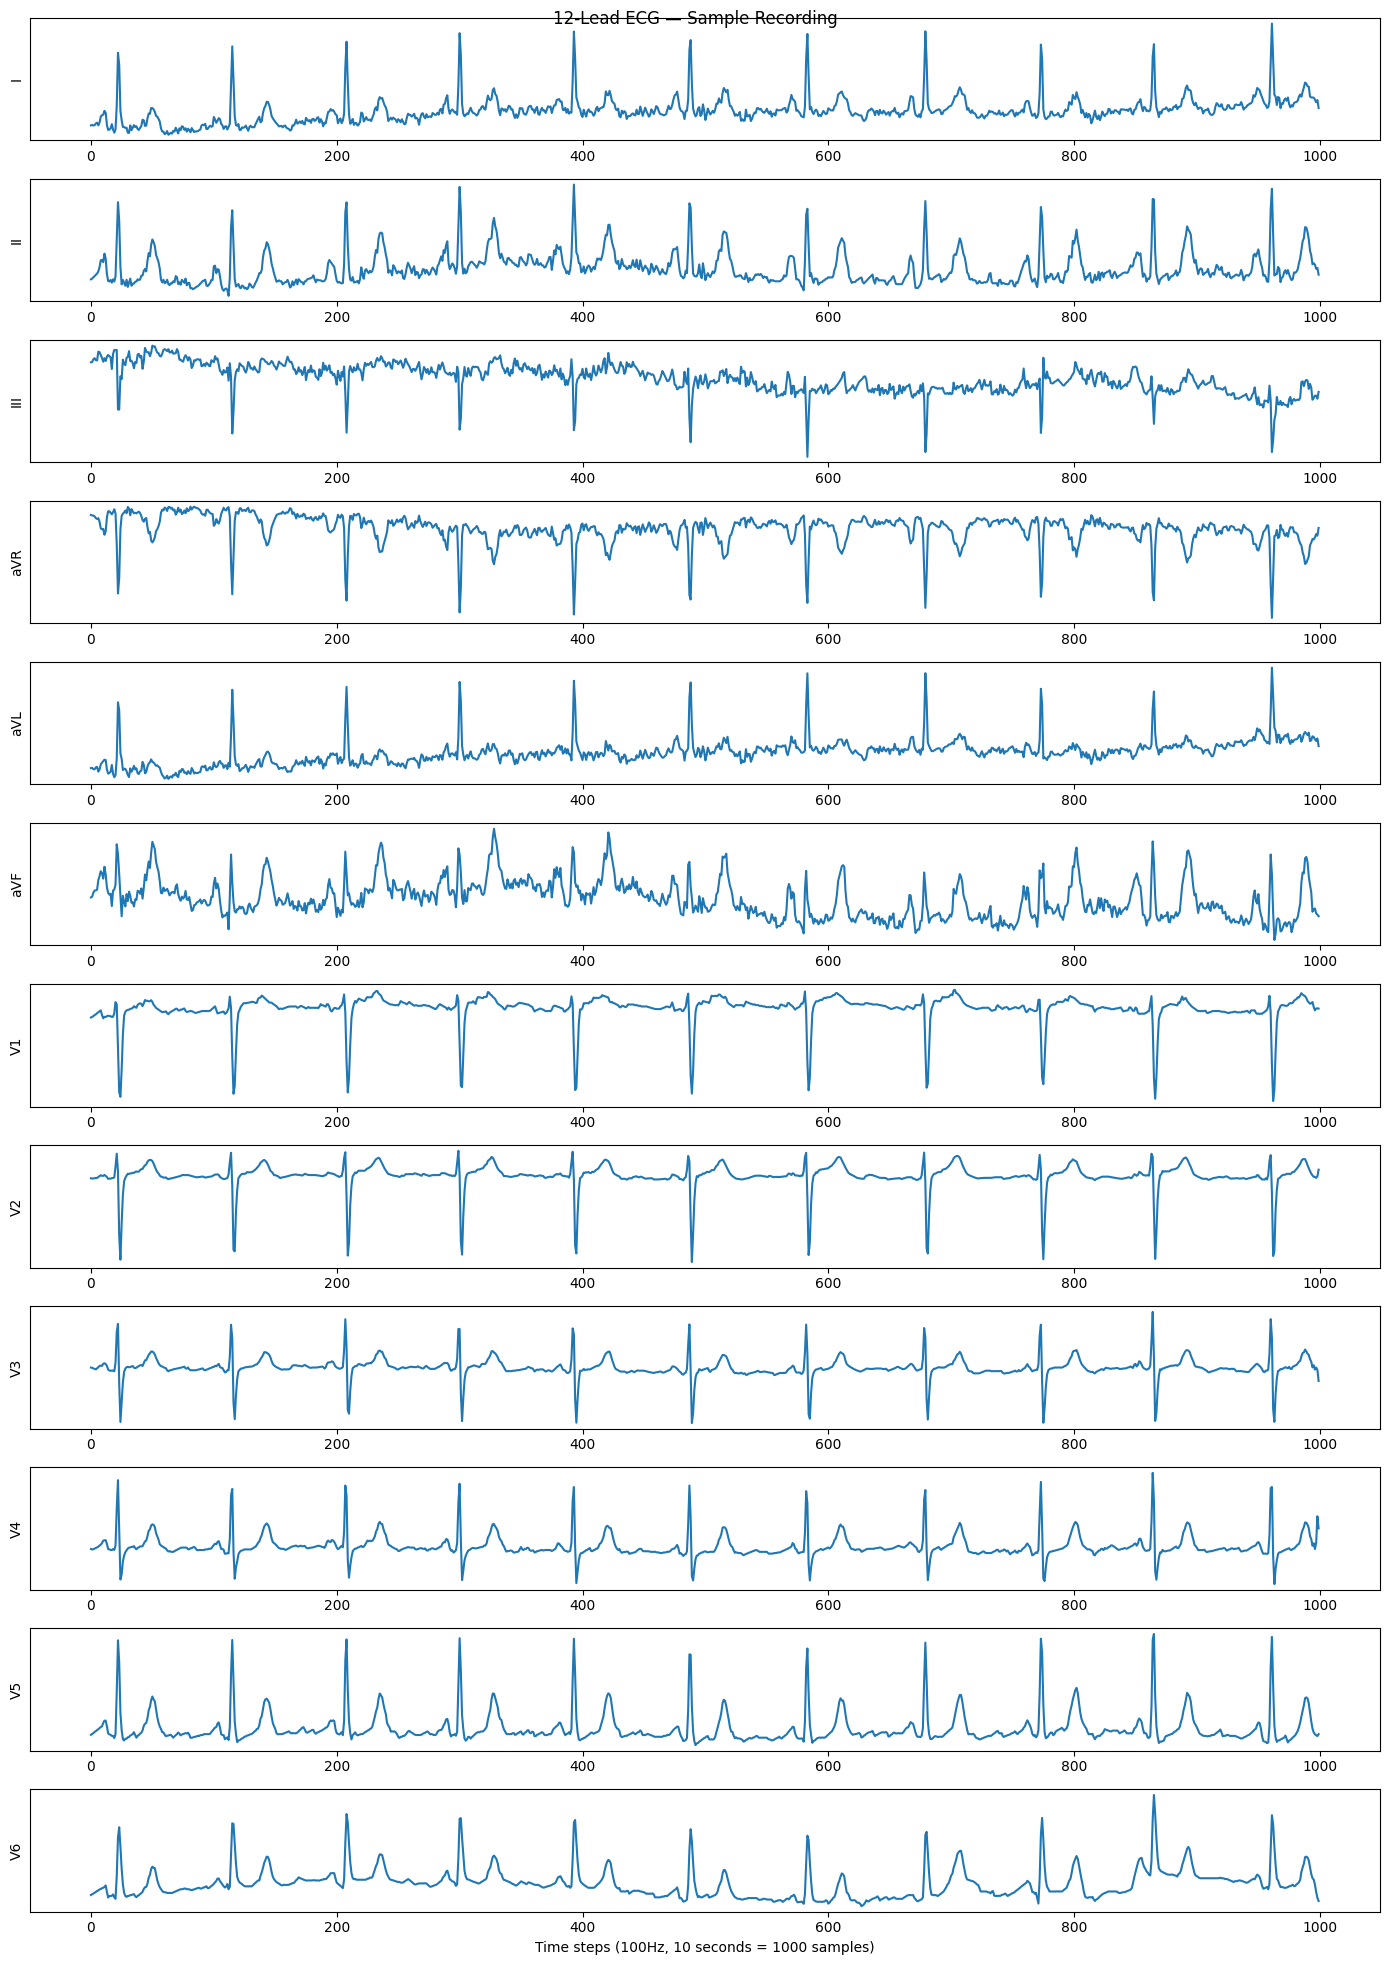

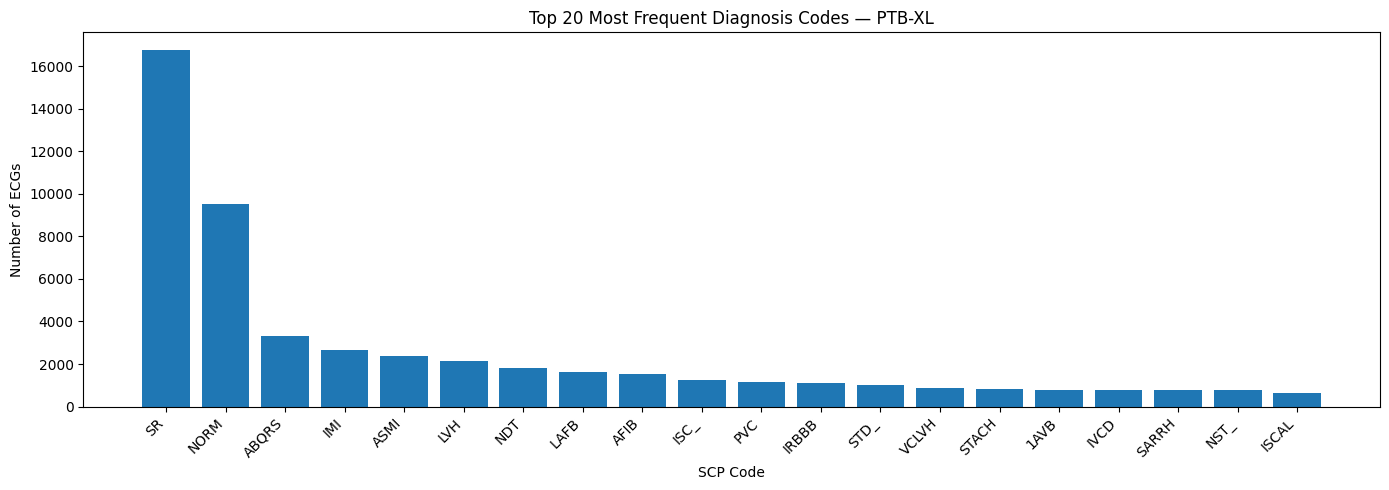

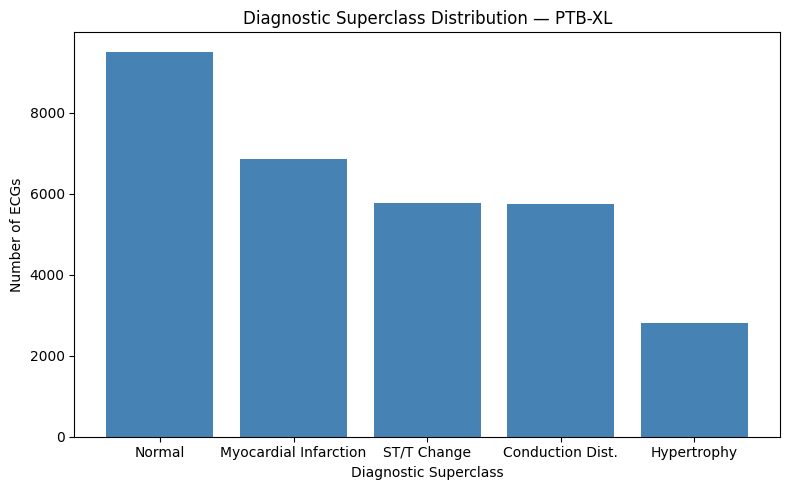

In [7]:
from google.colab import drive
drive.mount('/content/drive')

%run "/content/drive/MyDrive/Colab Notebooks/01_data_loading.ipynb"

In [9]:
# Load signals in batches and save as single .npy file
# This only needs to run ONCE — after that we load from the saved file instantly

import os

SAVE_PATH = '/content/drive/MyDrive/ptb-xl-dataset/'

# Check if already saved
if os.path.exists(SAVE_PATH + 'X_train.npy') and os.path.exists(SAVE_PATH + 'X_test.npy'):
    print("Loading from saved files...")
    X_train = np.load(SAVE_PATH + 'X_train.npy')
    X_test  = np.load(SAVE_PATH + 'X_test.npy')
    print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

else:
    print("First time loading — this takes ~10 minutes but only runs once...")

    def load_raw_data(df, path):
        data = [wfdb.rdsamp(path + f)[0] for f in df.filename_lr]
        return np.array(data)

    X_train = load_raw_data(train_df, DATA_PATH)
    X_test  = load_raw_data(test_df, DATA_PATH)

    np.save(SAVE_PATH + 'X_train.npy', X_train)
    np.save(SAVE_PATH + 'X_test.npy', X_test)

    print(f"Saved! X_train: {X_train.shape} | X_test: {X_test.shape}")

First time loading — this takes ~10 minutes but only runs once...
Saved! X_train: (19601, 1000, 12) | X_test: (2198, 1000, 12)


In [10]:
# Compute mean and std from training set ONLY
# This prevents feature leakage into the test set
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)
train_std[train_std == 0] = 1  # avoid divide by zero

# Apply training stats to both sets
X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print(f"X_train_norm: mean={X_train_norm.mean():.4f}, std={X_train_norm.std():.4f}")
print(f"X_test_norm:  mean={X_test_norm.mean():.4f},  std={X_test_norm.std():.4f}")

X_train_norm: mean=0.0000, std=1.0000
X_test_norm:  mean=0.0017,  std=0.9893


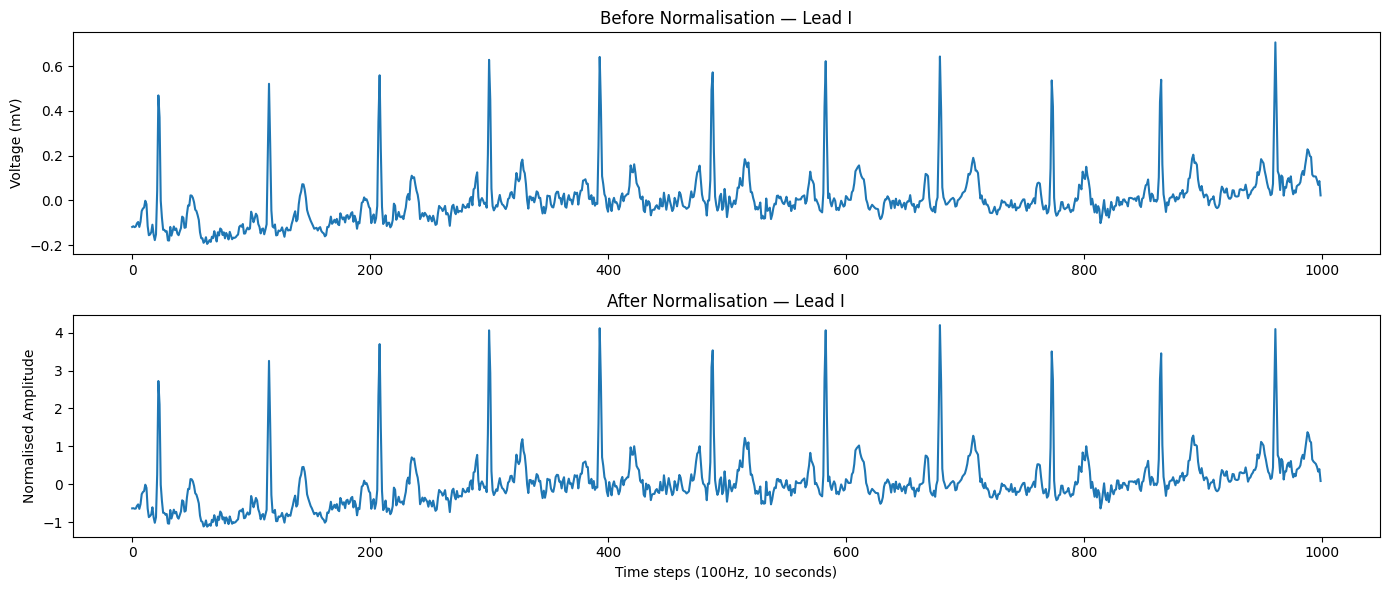

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(X_train[0, :, 0])
axes[0].set_title("Before Normalisation — Lead I")
axes[0].set_ylabel("Voltage (mV)")

axes[1].plot(X_train_norm[0, :, 0])
axes[1].set_title("After Normalisation — Lead I")
axes[1].set_ylabel("Normalised Amplitude")

axes[1].set_xlabel("Time steps (100Hz, 10 seconds)")
plt.tight_layout()
plt.savefig('normalisation.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Save normalised arrays to Drive for future use
np.save(SAVE_PATH + 'X_train_norm.npy', X_train_norm)
np.save(SAVE_PATH + 'X_test_norm.npy', X_test_norm)

print("Normalised data saved to Drive.")

Normalised data saved to Drive.


In [13]:
# Extract labels for train and test sets
y_train = train_df['diagnostic_superclass'].values
y_test  = test_df['diagnostic_superclass'].values

print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print(f"Sample labels: {y_train[:5]}")

y_train: (19601,) | y_test: (2198,)
Sample labels: [list(['NORM']) list(['NORM']) list(['NORM']) list(['NORM'])
 list(['NORM'])]


In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

# Define the 5 superclasses
classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

mlb = MultiLabelBinarizer(classes=classes)

# Convert list of labels to binary matrix
# Each row = one ECG, each column = one superclass (1=present, 0=absent)
y_train_enc = mlb.fit_transform(y_train)
y_test_enc  = mlb.transform(y_test)

print(f"y_train_enc shape: {y_train_enc.shape}")
print(f"y_test_enc shape:  {y_test_enc.shape}")
print(f"Sample encoding:   {y_train_enc[0]} → classes: {classes}")

y_train_enc shape: (19601, 5)
y_test_enc shape:  (2198, 5)
Sample encoding:   [1 0 0 0 0] → classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']


In [15]:
np.save(SAVE_PATH + 'y_train_enc.npy', y_train_enc)
np.save(SAVE_PATH + 'y_test_enc.npy', y_test_enc)

print("Labels saved to Drive.")

Labels saved to Drive.


In [16]:
import os

files = ['X_train.npy', 'X_test.npy', 'X_train_norm.npy',
         'X_test_norm.npy', 'y_train_enc.npy', 'y_test_enc.npy']

for f in files:
    path = SAVE_PATH + f
    size = os.path.getsize(path) / 1e6
    print(f"{f:25s} — {size:.1f} MB")

X_train.npy               — 1881.7 MB
X_test.npy                — 211.0 MB
X_train_norm.npy          — 1881.7 MB
X_test_norm.npy           — 211.0 MB
y_train_enc.npy           — 0.8 MB
y_test_enc.npy            — 0.1 MB
